In [1]:
import yfinance as yf
import numpy as np
import pandas as pd

from config import RAW_DATA_DIR

sp500 = pd.read_csv(RAW_DATA_DIR / "returns_SP500_ME.csv",index_col="Date", parse_dates=True)

df_raw = pd.read_csv(RAW_DATA_DIR / "dataset_paper1_monthly.csv",index_col="Date", parse_dates=True)
ffdata_df = df_raw.loc['1926-07-01':'2001-12-01', ['Mkt-RF', 'SMB', 'HML']]

In [2]:
from core.model_selection import evaluate_models, SeriesReport
from core import model_selection
from core import models
from core.empirical_evaluation import build_summary_table, plot_sr_intervals

In [16]:
def run(fit_models, series_list, series_names, avar_models, fit_to_avar_mapping, overrides):
    reports = evaluate_models(series_list=series_list, model_list=fit_models)
    df_summary = build_summary_table(
        series_list=series_list,
        reports=reports,
        avar_models=avar_models,
        series_names=series_names,
        alpha=0.05,
    )

    df_summary["SR"] = df_summary["SR"].round(4)
    print(df_summary.to_string())

    plot_sr_intervals(
        df_summary=df_summary,
        fit_to_avar_map=fit_to_avar_mapping,
        manual_overrides=overrides,
    )

In [17]:
fit_models = [
        model_selection.IIDNormal(),
        model_selection.IIDStudent(),
        model_selection.IIDSkewStudent(),
        model_selection.AR1Normal(),
        model_selection.AR1Student(),
    ]
fit_to_avar_mapping = {
    "iid_normal":      "IIDNormalModel",
    "iid_t":     "IIDStudentTModel",
    "iid_skew_t": "IIDNonNormalModel",
    "ar1_normal":      "AR1NormalModel",
    "ar1_t":     "AR1NonNormalModel",
}

overrides: dict[str, str] = {
    # "Pure IID Normal": "IIDNonNormalModel"
}

  Series    T      SR  CI_IIDNormalModel CI_IIDStudentTModel CI_IIDNonNormalModel  CI_AR1NormalModel CI_AR1NonNormalModel Best_Fit_BIC Ljung-Box ARCH-LM Breusch-Pagan  ADF KPSS Jarque-Bera Shapiro
0    SMB  906  0.0600  [-0.0052, 0.1251]   [-0.0057, 0.1257]    [-0.0019, 0.1218]  [-0.0100, 0.1300]    [-0.0066, 0.1266]        ar1_t        **     ***                ***              ***     ***
1    HML  906  0.1225   [0.0572, 0.1879]    [0.0549, 0.1902]     [0.0647, 0.1804]   [0.0426, 0.2025]     [0.0509, 0.1942]        ar1_t       ***     ***            **  ***              ***     ***


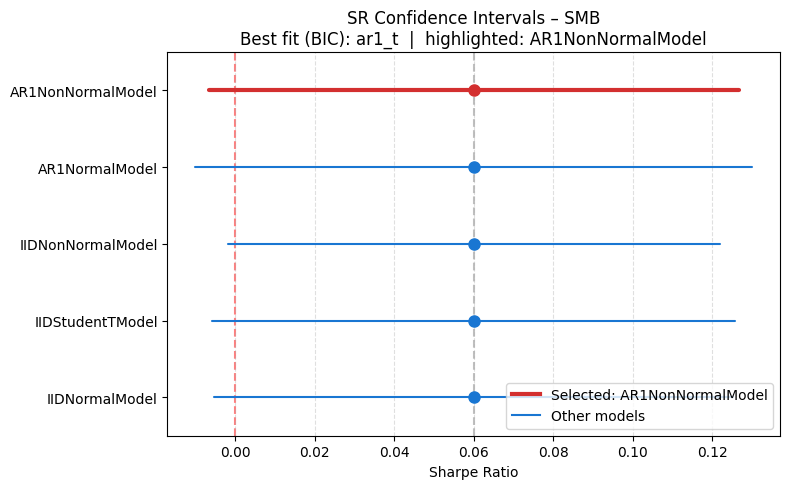

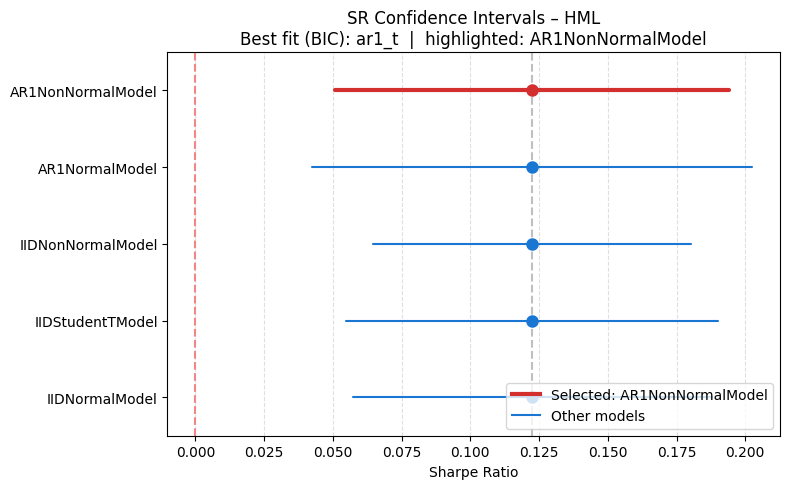

In [18]:
series_list=[ffdata_df["SMB"], ffdata_df["HML"]]
series_names = ["SMB", "HML"]

avar_models = [
    models.IIDNormalModel(),
    models.IIDStudentTModel(),
    models.IIDNonNormalModel(),
    models.AR1NormalModel(),
    models.AR1NonNormalModel(),
    #models.GARCH11Model(),
]

run(fit_models, series_list, series_names, avar_models, fit_to_avar_mapping, overrides)

   Series    T      SR CI_IIDNormalModel CI_IIDStudentTModel CI_IIDNonNormalModel CI_AR1NormalModel CI_AR1NonNormalModel   CI_GARCH11Model Best_Fit_BIC Ljung-Box ARCH-LM Breusch-Pagan  ADF KPSS Jarque-Bera Shapiro
0  Mkt-RF  906  0.1199  [0.0546, 0.1853]    [0.0537, 0.1862]     [0.0547, 0.1852]  [0.0472, 0.1926]     [0.0474, 0.1924]  [0.0645, 0.1754]   iid_skew_t       ***     ***           ***  ***              ***     ***
1   SP500  914  0.1543  [0.0890, 0.2195]    [0.0886, 0.2199]     [0.0855, 0.2230]  [0.0875, 0.2210]     [0.0840, 0.2245]  [0.0392, 0.2693]   iid_skew_t               ***                ***              ***     ***


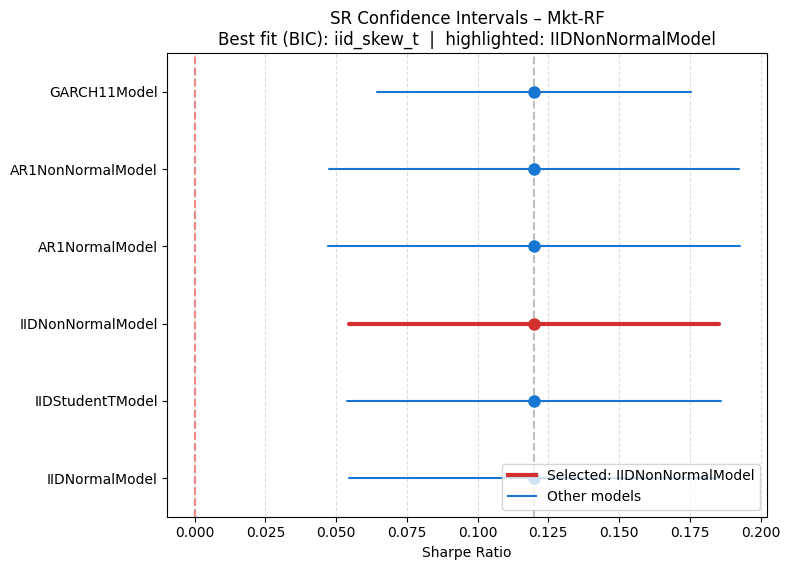

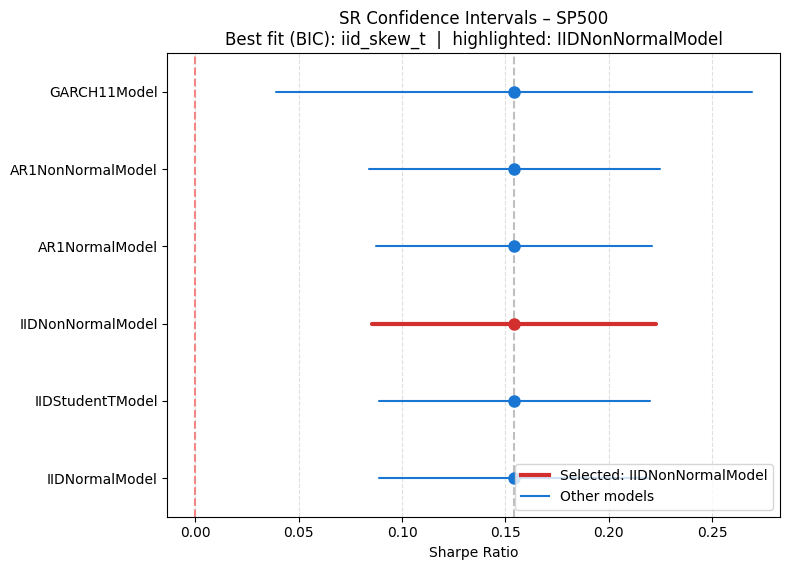

In [20]:
series_list=[ffdata_df["Mkt-RF"], sp500['SP500']]
series_names = ["Mkt-RF", "SP500"]

avar_models = [
    models.IIDNormalModel(),
    models.IIDStudentTModel(),
    models.IIDNonNormalModel(),
    models.AR1NormalModel(),
    models.AR1NonNormalModel(),
    models.GARCH11Model(),
]

run(fit_models, series_list, series_names, avar_models, fit_to_avar_mapping, overrides)

In [22]:
m = models.GARCH11Model()
params = m.fit(sp500["SP500"])
params

{'omega': np.float64(0.01025340862140182),
 'alpha': np.float64(0.11787585760786116),
 'beta': np.float64(0.8300523196964774),
 'skew': -0.6477213406997013,
 'exc_kurt': 2.1622554940940653}

In [ ]:
m.avar()